# Análisis del inventario del almacén

**Objetivo:** explorar con pandas los productos y movimientos que registra la app, calcular los indicadores que usa el menú y sacar conclusiones para el dueño del almacén.

La notebook **no repite la lógica**: importa los mismos módulos que `main.py` (`persistencia` para leer los archivos, `Inventario` para las reglas, `analisis` para los indicadores y gráficos). Si cambia un cálculo, cambia en los dos lados.

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

import analisis
import persistencia
from inventario import Inventario

inventario = Inventario(persistencia.cargar_productos(), persistencia.cargar_movimientos())
print(f"{len(inventario.productos)} productos y {len(inventario.movimientos)} movimientos cargados")

16 productos y 72 movimientos cargados


## 1. Productos

Cada producto de `datos/productos.json` es una fila. `describe()` resume las columnas numéricas.

In [2]:
productos = analisis.productos_a_dataframe(inventario)
productos.head()

,codigo,nombre,categoria,precio,stock,stock_minimo
0,A001,Yerba mate 500g,almacen,2500.0,6,10
1,A002,Azúcar 1kg,almacen,1400.0,25,10
2,A003,Fideos spaghetti 500g,almacen,1100.0,30,12
3,A004,Arroz largo fino 1kg,almacen,1600.0,9,8
4,A005,Aceite de girasol 900ml,almacen,3200.0,4,6


In [3]:
productos[["precio", "stock", "stock_minimo"]].describe().round(1)

,precio,stock,stock_minimo
count,16.0,16.0,16.0
mean,1753.1,18.0,11.6
std,984.8,14.5,5.9
min,450.0,0.0,4.0
25%,1100.0,6.8,7.5
50%,1500.0,13.0,10.0
75%,2525.0,26.2,15.0
max,3800.0,50.0,24.0


In [4]:
productos["categoria"].value_counts()

categoria
almacen      5
bebidas      4
limpieza     4
golosinas    3
Name: count, dtype: int64

## 2. Movimientos

Cada fila de `datos/movimientos.csv` es una entrada (llegó mercadería) o una salida (se vendió). Primero, cuántas unidades entraron y salieron en total.

In [5]:
movimientos = analisis.movimientos_a_dataframe(inventario)
movimientos.groupby("tipo")["cantidad"].agg(["count", "sum"])

,count,sum
tipo,,
entrada,10,114
salida,62,279


Salieron más del doble de unidades de las que entraron: el stock se está consumiendo más rápido de lo que se repone. Así se ven las ventas día por día:

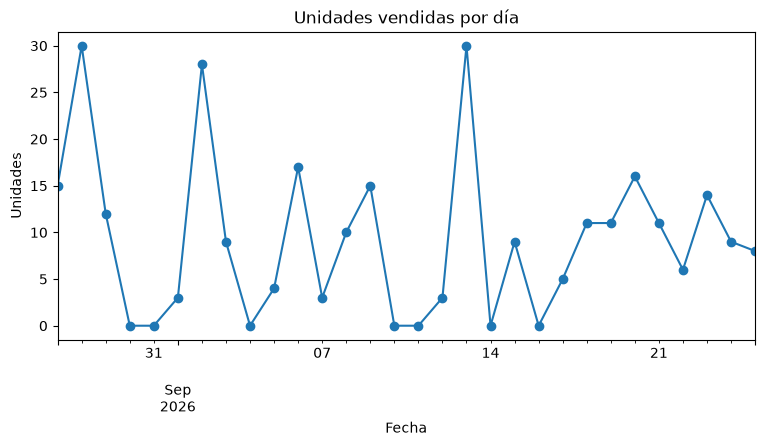

Promedio: 9.3 unidades por día · días sin ventas: 7


In [6]:
ventas = analisis.ventas_por_dia(inventario)
eje = ventas.plot(x="fecha", y="unidades", marker="o", figsize=(9, 4), legend=False,
                  title="Unidades vendidas por día")
eje.set_xlabel("Fecha")
eje.set_ylabel("Unidades")
plt.show()
print(f"Promedio: {ventas['unidades'].mean():.1f} unidades por día · "
      f"días sin ventas: {(ventas['unidades'] == 0).sum()}")

## 3. Indicadores

### 3.1 Valor del inventario
Cuánta plata hay inmovilizada en stock (precio × stock), total y por categoría.

In [7]:
print(f"Valor total: $ {analisis.valor_total_inventario(inventario):,.2f}")
valor_por_categoria = analisis.analizar_valor_inventario(inventario)
valor_por_categoria

Valor total: $ 423,000.00


,categoria,productos,unidades,valor
1,bebidas,4,80,154300.0
0,almacen,5,74,110200.0
2,golosinas,3,92,86700.0
3,limpieza,4,42,71800.0


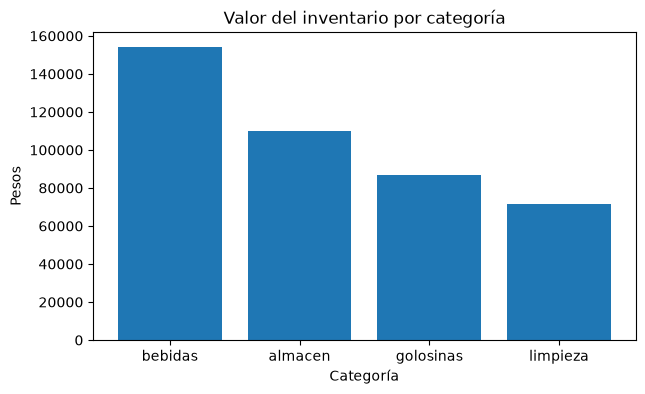

In [8]:
figura, eje = plt.subplots(figsize=(7, 4))
eje.bar(valor_por_categoria["categoria"], valor_por_categoria["valor"], color="#1f77b4")
eje.set_title("Valor del inventario por categoría")
eje.set_xlabel("Categoría")
eje.set_ylabel("Pesos")
plt.show()

### 3.2 Días de cobertura
Consumo diario = unidades vendidas en los últimos 30 días / 30. Días de cobertura = stock / consumo diario: cuántos días dura lo que hay si se sigue vendiendo igual. Complementa la alerta por stock mínimo: un producto puede estar arriba del mínimo y durar pocos días.

In [9]:
analisis.analizar_cobertura(inventario).head(10)

,codigo,nombre,stock,consumo_diario,dias_cobertura
6,B002,Agua mineral 1.5L,0,1.300000,0.000000
0,A001,Yerba mate 500g,6,1.000000,6.000000
4,A005,Aceite de girasol 900ml,4,0.466667,8.571429
13,G002,Chocolate 100g,7,0.600000,11.666667
10,L002,Detergente 500ml,5,0.333333,15.000000
3,A004,Arroz largo fino 1kg,9,0.400000,22.500000
5,B001,Gaseosa cola 2.25L,18,0.800000,22.500000
12,G001,Alfajor triple,35,1.100000,31.818182
7,B003,Cerveza lata 473ml,40,1.000000,40.000000
11,L003,Papel higiénico x4,14,0.300000,46.666667


### 3.3 Productos más vendidos

In [10]:
analisis.analizar_mas_vendidos(inventario)

,codigo,nombre,categoria,vendido
6,B002,Agua mineral 1.5L,bebidas,39
12,G001,Alfajor triple,golosinas,33
0,A001,Yerba mate 500g,almacen,30
7,B003,Cerveza lata 473ml,bebidas,30
5,B001,Gaseosa cola 2.25L,bebidas,24


### 3.4 Productos sin ventas en el período (stock inmovilizado)

In [11]:
analisis.analizar_sin_movimiento(inventario)

,codigo,nombre,stock,valor
15,L004,Esponja de cocina,12,8400.0


## 4. Alertas de reabastecimiento

Un producto está en alerta si su stock es menor o igual al mínimo. La cantidad sugerida lleva el stock al doble del mínimo.

In [12]:
for producto in inventario.alertas():
    print(f"{producto.nombre:<26} stock {producto.stock:>3} · mínimo {producto.stock_minimo:>3} · "
          f"pedir {producto.cantidad_sugerida():>3} · $ {producto.costo_reposicion():>10,.2f}")
print(f"Total a invertir: $ {inventario.costo_total_reposicion():,.2f}")

Agua mineral 1.5L          stock   0 · mínimo  15 · pedir  30 · $  36,000.00
Yerba mate 500g            stock   6 · mínimo  10 · pedir  14 · $  35,000.00
Aceite de girasol 900ml    stock   4 · mínimo   6 · pedir   8 · $  25,600.00
Chocolate 100g             stock   7 · mínimo  10 · pedir  13 · $  33,800.00
Detergente 500ml           stock   5 · mínimo   5 · pedir   5 · $   8,500.00
Total a invertir: $ 138,900.00


El mismo gráfico que genera la opción 13 del menú: en rojo los productos a reponer, la marca negra es el stock mínimo.

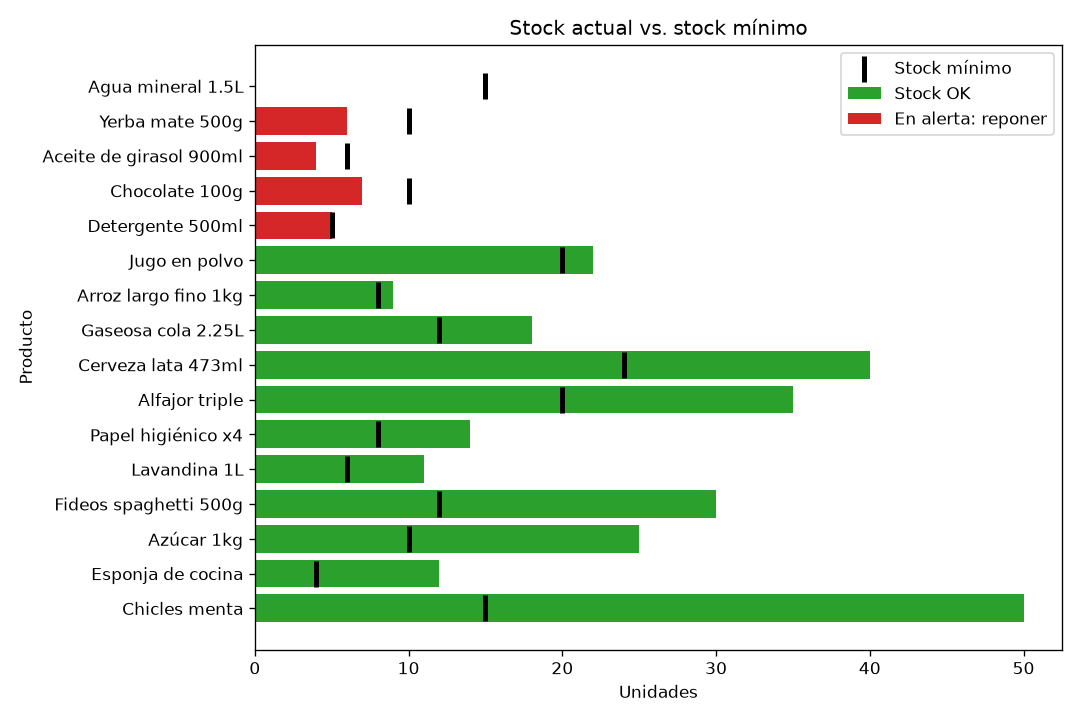

In [13]:
ruta = analisis.graficar_stock_vs_minimo(inventario, ruta="graficos/stock_vs_minimo.png")
display(Image(filename=ruta))

## 5. Fuente externa: cotización del dólar

`fuente_externa.obtener_cotizacion()` consulta la API pública de DolarApi. Si no hay internet, usa la última cotización guardada en `datos/cotizacion.json` y lo indica en `origen`.

In [14]:
import fuente_externa

cotizacion = fuente_externa.obtener_cotizacion()
print(cotizacion)
analisis.analizar_valor_inventario(inventario, cotizacion["venta"])

{'venta': 1545.0, 'fecha': '2026-09-25', 'origen': 'api'}


,categoria,productos,unidades,valor,valor_usd
1,bebidas,4,80,154300.0,99.870550
0,almacen,5,74,110200.0,71.326861
2,golosinas,3,92,86700.0,56.116505
3,limpieza,4,42,71800.0,46.472492


## Conclusiones

- **Hay que reponer 5 productos** por unos **$ 138.900**. El más urgente es el agua mineral: no queda stock y es el producto que más se vende (39 unidades en 30 días).
- La yerba (6 días de cobertura) y el aceite (menos de 9) se terminan en una semana al ritmo actual: conviene incluirlos en el próximo pedido aunque falten pocas unidades para el mínimo.
- Hay **$ 423.000 inmovilizados** en stock. Bebidas concentra más de un tercio.
- La esponja de cocina no tuvo ventas en 30 días: no hace falta reponerla y conviene revisar si se sigue comprando.
- Salieron 279 unidades y entraron 114: sin reposición, cada vez más productos van a entrar en alerta.

**Decisión del dueño:** exportar la orden de compra (opción 11 del menú), priorizar agua, yerba y aceite, y bajar el stock mínimo de la esponja.

Con la cotización del dólar, el valor del inventario y el costo de reposición se pueden comparar con meses anteriores sin que la inflación distorsione la comparación.